<a href="https://colab.research.google.com/github/nguyen23012007/MY_PROJECT/blob/main/BTVNNHANDIEN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# 1. TIỀN XỬ LÝ DỮ LIỆU

# Thiết lập đường dẫn dữ liệu
train_dir = "/content/drive/MyDrive/File ảnh lớp"

# Kích thước ảnh và kích thước lô
img_width, img_height = 128, 128
batch_size = 32

# Tăng cường dữ liệu dành cho huấn luyện mô hình
train_datagen = ImageDataGenerator(
    rescale=1.0/255,      # Normalize pixel values
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)

In [2]:
# Tải dữ liệu huấn luyện
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode="categorical"
)

# XÂY DỰNG MÔ HÌNH CNN
model = Sequential([
    Conv2D(32, (3,3), activation="relu", input_shape=(img_width, img_height, 3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation="relu"),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation="relu"),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5), # Reduce overfitting
    Dense(train_generator.num_classes, activation="softmax") # Corrected to match the number of classes in the training data
])

Found 2176 images belonging to 37 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 37)             │         4,773 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,309,413 (12.62 MB)

 Trainable params: 3,309,413 (12.62 MB)

 Non-trainable params: 0 (0.00 B)

Training without validation data due to an issue with validation_generator setup.
Epoch 1/15
68/68 ━━━━━━━━━━━━━━━━━━━━ 1670s 24s/step - accuracy: 0.0593 - loss: 3.5263
Epoch 2/15
68/68 ━━━━━━━━━━━━━━━━━━━━ 17s 257ms/step - accuracy: 0.1544 - loss: 3.1153
Epoch 3/15
68/68 ━━━━━━━━━━━━━━━━━━━━ 19s 275ms/step - accuracy: 0.2468 - loss: 2.7672
Epoch 4/15
68/68 ━━━━━━━━━━━━━━━━━━━━ 18s 259ms/step - accuracy: 0.3566 - loss: 2.3812
Epoch 5/15
68/68 ━━━━━━━━━━━━━━━━━━━━ 18s 263ms/step - accuracy: 0.4329 - loss: 2.0294
Epoch 6/15
68/68 ━━━━━━━━━━━━━━━━━━━━ 17s 257ms/step - accuracy: 0.4931 - loss: 1.8377
Epoch 7/15
68/68 ━━━━━━━━━━━━━━━━━━━━ 19s 274ms/step - accuracy: 0.5542 - loss: 1.6305
Epoch 8/15
68/68 ━━━━━━━━━━━━━━━━━━━━ 18s 258ms/step - accuracy: 0.5896 - loss: 1.4922
Epoch 9/15
68/68 ━━━━━━━━━━━━━━━━━━━━ 18s 263ms/step - accuracy: 0.6438 - loss: 1.3181
Epoch 10/15
68/68 ━━━━━━━━━━━━━━━━━━━━ 18s 263ms/step - accuracy: 0.6604 - loss: 1.2217
Epoch 11/15
68/68 ━━━━━━━━━━━━━━━━━━━━ 19s 282m

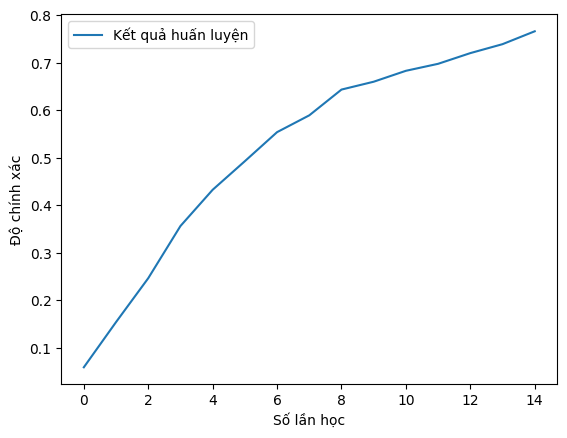

In [3]:
# Biên dịch mô hình
model.compile(optimizer="adam",
              loss="categorical_crossentropy",
              metrics=["accuracy"])

# Tóm tắt cấu hình của mô hình
model.summary()

# --- Start of suggested additions for validation data ---
# NOTE: To get 'val_accuracy', you need a separate directory for validation data.
# Please replace "/content/drive/MyDrive/File ảnh lớp_validation" with your actual validation directory path.
# If you don't have a separate validation directory, you'll need to create one and move some images there.
validation_dir = "/content/drive/MyDrive/File ảnh lớp_validation" # Placeholder for validation data path

# Prepare validation data generator (typically only rescaling, no heavy augmentation for validation)
validation_datagen = ImageDataGenerator(rescale=1.0/255)

# Load validation data
# Ensure validation_dir exists and contains subdirectories for classes, matching your training data structure.
try:
    validation_generator = validation_datagen.flow_from_directory(
        validation_dir,
        target_size=(img_width, img_height),
        batch_size=batch_size,
        class_mode="categorical"
    )
    print(f"Found {validation_generator.num_classes} classes in validation data.")
except Exception as e:
    print(f"Warning: Could not create validation_generator. Please ensure 'validation_dir' is correctly set and accessible. Error: {e}")
    # If validation_generator fails, set it to None to avoid subsequent errors
    validation_generator = None
# --- End of suggested additions for validation data ---

# HUẤN LUYỆN MÔ HÌNH CNN
epochs = 15
# Pass validation_data if validation_generator was successfully created
if validation_generator:
    history = model.fit(train_generator,
                        epochs=epochs,
                        validation_data=validation_generator)
else:
    # Train without validation data if generator could not be created
    print("Training without validation data due to an issue with validation_generator setup.")
    history = model.fit(train_generator, epochs=epochs)


# ĐÁNH GIÁ KẾT QUẢ MÔ HÌNH
plt.plot(history.history['accuracy'], label="Kết quả huấn luyện")

# Only plot val_accuracy if it's available in the history object
if 'val_accuracy' in history.history:
    plt.plot(history.history['val_accuracy'], label="Độ chính xác xác thực")
else:
    print("Validation accuracy ('val_accuracy') not available in history.history because validation_data was not used during training.")

plt.xlabel("Số lần học")
plt.ylabel("Độ chính xác")
plt.legend()
plt.show()

# IMPORTANT NOTE: The train_generator found 37 classes, but your model's last dense layer
# `Dense(6, activation="softmax")` is configured for 6 classes.
# This mismatch will cause an error during training if the number of classes in your data
# does not match the output layer's dimension. You likely need to change the `Dense` layer in your model definition
# (e.g., in cell `l5P4Q8MKKe_j`) to `Dense(train_generator.num_classes, activation="softmax")`.

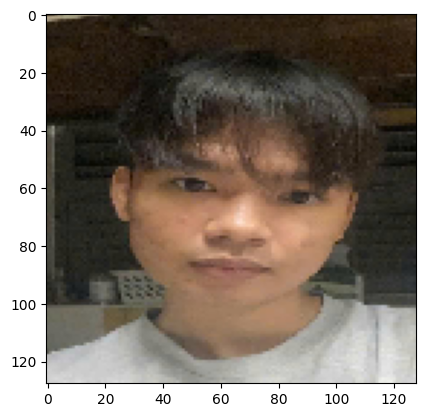

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
Người tiên đoán: Danh Nguyên


In [13]:
# Tải và tiền xử lý ảnh kiểm tra
from keras.utils import load_img
import numpy as np

path = "/content/N7.jpg"

# Tiên đoán loại
img = load_img(path, target_size=(128, 128))

plt.imshow(img)
plt.show()

img = np.array(img)
img = img / 255.0
img = img.reshape(1, 128, 128, 3)

prediction = np.argmax(model.predict(img))

# Ánh xạ loại tới tên người
class_labels = {v: k for k, v in train_generator.class_indices.items()}

person_name = class_labels[prediction]

print(f"Người tiên đoán: {person_name}")

In [ ]:
# To install a library, use the `!pip install` command followed by the library name.
# For example, to install the 'requests' library, you would run:
# !pip install requests

# If you need to install multiple libraries, you can list them like this:
# !pip install library1 library2

# For specific versions, use '==':
# !pip install pandas==1.5.3

# Uncomment and run the line below to install a hypothetical library:
# !pip install example-library

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Once your Google Drive is mounted, you can load a file (e.g., a CSV file) by specifying its path. Replace `'path/to/your/file.csv'` with the actual path to your file in Google Drive.

In [ ]:
import pandas as pd

# Example: Load a CSV file from Google Drive
# Replace 'path/to/your/file.csv' with the actual path to your file
file_path = '/content/drive/MyDrive/path/to/your/file.csv'
try:
    df = pd.read_csv(file_path)
    print("File loaded successfully!")
    display(df.head())
except FileNotFoundError:
    print(f"Error: The file at {file_path} was not found. Please check the path.")
except Exception as e:
    print(f"An error occurred while loading the file: {e}")

Error: The file at /content/drive/MyDrive/path/to/your/file.csv was not found. Please check the path.
